How are in-demand skills trending for Data Analysts?

- Methology
- Aggregate skill counts monthly
- Re-analyze based on percentage of total jobs
- Plot the monthly skill demand
- Original Exploration
- 12_Exercise_Trending_Skills.ipynb

In [1]:

# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_VN = df[(df['job_title_short']=='Data Analyst')&(df['job_location']=='Vietnam')].copy()

In [4]:
df_DA_VN


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3056,Data Analyst,Chuyên Viên Phân Tích Dữ Liệu (Data Analyst),Vietnam,via Glints,Full-time,False,Vietnam,2023-10-18 13:29:13,True,False,Vietnam,NaN,NaN,NaN,Công ty Cổ phần Dịch vụ Giao Hàng Nhanh,"[sql, python, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
31673,Data Analyst,[SO] Senior Data Analyst,Vietnam,via AI Careers,Full-time,False,Vietnam,2023-05-30 13:16:07,True,False,Vietnam,NaN,NaN,NaN,Bosch Group,NaN,NaN
41649,Data Analyst,Digital Marketing Data Analyst (GG & FB),Vietnam,via LinkedIn,Full-time,False,Vietnam,2023-10-03 06:12:56,False,False,Vietnam,NaN,NaN,NaN,Getz Group,NaN,NaN
55725,Data Analyst,Data Manager,Vietnam,via CareerBuilder,Full-time,False,Vietnam,2023-10-26 06:27:17,True,False,Vietnam,NaN,NaN,NaN,Công ty Cổ phần Thời Trang YODY,NaN,NaN
62923,Data Analyst,Merchandise Data Analyst,Vietnam,via LinkedIn Vietnam,Full-time,False,Vietnam,2023-07-11 06:47:07,False,False,Vietnam,NaN,NaN,NaN,Central Retail in Vietnam,"[go, outlook, power bi]","{'analyst_tools': ['outlook', 'power bi'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715264,Data Analyst,Data Analyst,Vietnam,via LinkedIn Vietnam,Full-time,False,Vietnam,2023-06-23 02:22:17,True,False,Vietnam,NaN,NaN,NaN,Thuận Hải Energy,NaN,NaN
732003,Data Analyst,[SO] Data Analyst (EN),Vietnam,via Ai-Jobs.net,Full-time,False,Vietnam,2023-02-23 21:37:17,True,False,Vietnam,year,51014.0,NaN,Bosch Group,"[java, sql, python, sql server, oracle, sap]","{'analyst_tools': ['sap'], 'cloud': ['oracle']..."
742723,Data Analyst,Data Analyst,Vietnam,via Vn.linkedin.com,Full-time,False,Vietnam,2023-07-13 20:18:11,True,False,Vietnam,NaN,NaN,NaN,Viettel Big Data Analytics Center,"[sql, nosql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
753288,Data Analyst,SO Data Analyst,Vietnam,via Ai-Jobs.net,Full-time,False,Vietnam,2023-12-07 20:53:18,False,False,Vietnam,year,75550.0,NaN,Bosch Group,"[java, sql, python, sql server, oracle, sap]","{'analyst_tools': ['sap'], 'cloud': ['oracle']..."


In [6]:
df_DA_VN['job_posted_month_no'] = df_DA_VN['job_posted_date'].dt.month

In [7]:
df_DA_VN_explode = df_DA_VN.explode('job_skills')

In [8]:
df_DA_VN_pivot = df_DA_VN_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

In [9]:
df_DA_VN_pivot


job_skills,airflow,alteryx,aws,azure,bigquery,c,c++,cassandra,databricks,excel,...,spreadsheet,spring,spss,sql,sql server,tableau,terminal,vba,visio,word
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,5,...,0,0,0,5,0,2,0,0,0,1
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,5,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,2,...,0,0,0,3,0,1,0,0,0,1
4,0,0,1,1,0,1,1,0,1,3,...,0,1,1,5,0,3,0,1,0,0
5,0,0,0,0,0,0,0,0,0,2,...,0,0,0,3,0,2,0,0,1,1
6,0,1,2,1,0,0,0,0,0,6,...,0,0,0,5,0,2,0,3,0,1
7,1,0,0,0,1,0,0,0,0,5,...,0,0,0,7,0,2,0,1,0,0
8,0,0,0,0,0,0,0,0,0,3,...,0,0,1,3,0,1,0,1,0,0
9,0,0,1,0,0,0,0,1,0,5,...,1,0,0,4,0,4,0,0,0,1


In [10]:
# sorts by count
df_DA_VN_pivot.loc['Total'] = df_DA_VN_pivot.sum()
df_DA_VN_pivot = df_DA_VN_pivot[df_DA_VN_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_VN_pivot = df_DA_VN_pivot.drop('Total')

df_DA_VN_pivot

job_skills,sql,excel,power bi,python,tableau,sas,r,sap,powerpoint,vba,...,c,mariadb,php,looker,sharepoint,scala,spring,spreadsheet,terminal,visio
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,5,5,4,1,2,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,5,1,1,3,0,0,2,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,2,2,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,5,3,0,3,3,4,1,1,0,1,...,1,0,0,0,0,0,1,0,0,0
5,3,2,3,1,2,2,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
6,5,6,2,3,2,2,1,2,0,3,...,0,0,1,0,0,0,0,0,0,0
7,7,5,4,3,2,0,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0
8,3,3,0,0,1,4,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,4,5,3,1,4,0,0,0,2,0,...,0,1,0,0,0,0,0,1,0,0


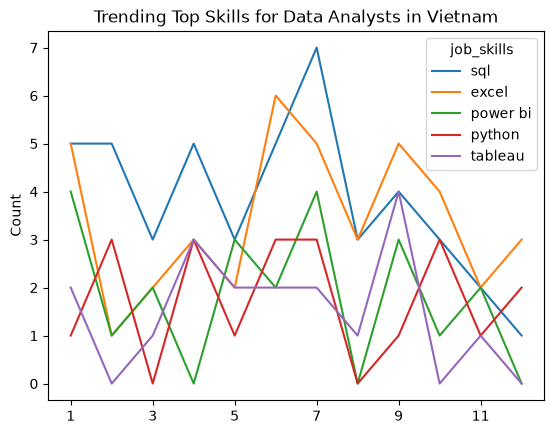

In [11]:
df_DA_VN_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Analysts in Vietnam')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [12]:
# Get monthly totals
DA_totals = df_DA_VN.groupby('job_posted_month_no').size()

DA_totals

job_posted_month_no
1     13
2      7
3      6
4      8
5      4
6     11
7     10
8      4
9      8
10    10
11     4
12     6
dtype: int64

In [13]:
# divide first 12 rows of df_DA_pivot by DA_totals
df_DA_VN_percent = df_DA_VN_pivot.iloc[:12].div(DA_totals/100, axis=0)

# changes month number to month name
df_DA_VN_percent = df_DA_VN_percent.reset_index()
df_DA_VN_percent['job_posted_month'] = df_DA_VN_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_VN_percent = df_DA_VN_percent.set_index('job_posted_month')
df_DA_VN_percent = df_DA_VN_percent.drop(columns='job_posted_month_no')

df_DA_VN_percent

job_skills,sql,excel,power bi,python,tableau,sas,r,sap,powerpoint,vba,...,c,mariadb,php,looker,sharepoint,scala,spring,spreadsheet,terminal,visio
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,38.461538,38.461538,30.769231,7.692308,15.384615,0.000000,7.692308,0.000000,7.692308,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,7.692308,0.0,0.0,0.0,0.0
Feb,71.428571,14.285714,14.285714,42.857143,0.000000,0.000000,28.571429,14.285714,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
Mar,50.000000,33.333333,33.333333,0.000000,16.666667,0.000000,0.000000,0.000000,16.666667,0.000000,...,0.0,0.0,0.000000,0.0,16.666667,0.000000,0.0,0.0,0.0,0.0
Apr,62.500000,37.500000,0.000000,37.500000,37.500000,50.000000,12.500000,12.500000,0.000000,12.500000,...,12.5,0.0,0.000000,0.0,0.000000,0.000000,12.5,0.0,0.0,0.0
May,75.000000,50.000000,75.000000,25.000000,50.000000,50.000000,25.000000,0.000000,25.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,25.0
Jun,45.454545,54.545455,18.181818,27.272727,18.181818,18.181818,9.090909,18.181818,0.000000,27.272727,...,0.0,0.0,9.090909,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
Jul,70.000000,50.000000,40.000000,30.000000,20.000000,0.000000,10.000000,10.000000,0.000000,10.000000,...,0.0,0.0,0.000000,10.0,0.000000,0.000000,0.0,0.0,0.0,0.0
Aug,75.000000,75.000000,0.000000,0.000000,25.000000,100.000000,0.000000,0.000000,0.000000,25.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
Sep,50.000000,62.500000,37.500000,12.500000,50.000000,0.000000,0.000000,0.000000,25.000000,0.000000,...,0.0,12.5,0.000000,0.0,0.000000,0.000000,0.0,12.5,0.0,0.0


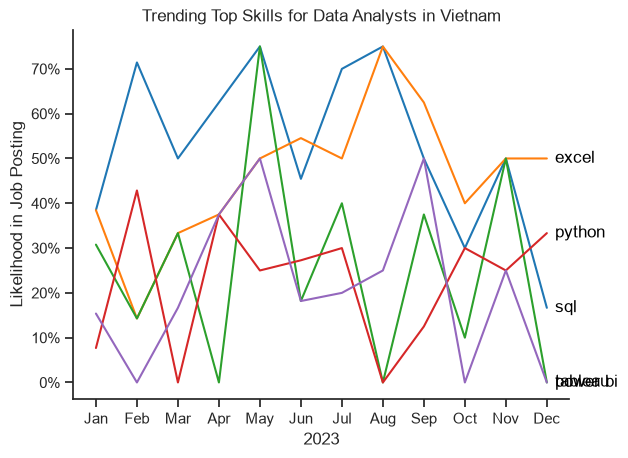

In [18]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DA_VN_percent.iloc[:, :5]
sns.set_theme(style='ticks')

sns.lineplot(
    data=df_plot,
    dashes=False,
    legend='full',
    palette='tab10'
)
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Data Analysts in Vietnam')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    y = df_plot.iloc[-1, i]

    # Check previous labels and move this one if too close
    for j in range(i):
        previous_y = df_plot.iloc[-1, j]

        if abs(y - previous_y) < 0.05:
            y += 0.05

    plt.text(
        11.2,
        y,
        df_plot.columns[i],
        color='black',
        va='center'
    )

plt.show()